# Advanced Models: XGBoost and CatBoost

In this notebook, we explore gradient boosting methods to improve upon our baseline Random Forest:

1. **XGBoost** - Extreme Gradient Boosting with native NaN handling
2. **CatBoost** - Categorical Boosting with native categorical feature support
3. **Hyperparameter Optimization** - Using RandomizedSearchCV

## Introduction to Gradient Boosting

While Random Forest builds trees independently in parallel (**bagging**), gradient boosting builds trees sequentially, with each tree correcting the errors of the previous ensemble.

**Key advantages:**
- Often achieves better performance than random forests on structured/tabular data
- Native missing value handling (learns optimal splits for NaN)
- Regularization parameters to prevent overfitting

**Trade-offs:**
- More hyperparameters to tune
- Sequential training (slower than parallel random forest)
- More prone to overfitting if not regularized

## Data Loading

In [ ]:
from src.data_loader import load_thyroid_data_3_classes
from src.metrics import thyroid_recall_scorer
from src.preprocessing import get_native_nan_pipeline

X_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)

## XGBoost

XGBoost handles missing values natively by learning the optimal direction to route samples with missing features at each split. This makes imputation unnecessary for XGBoost.

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Label mapping: {'hyperthyroid': 0, 'hypothyroid': 1, 'negative': 2}


In [ ]:
preprocessor = get_native_nan_pipeline()

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

In [ ]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_xgb = cross_val_score(
    pipeline_xgb, X_train, y_train_encoded,
    cv=stratified_cv,
    scoring=thyroid_recall_scorer
)

print(f"XGBoost - Thyroid Mean Recall")
print(f"  Per-fold scores: {scores_xgb.round(3)}")
print(f"  Mean: {scores_xgb.mean():.3f} (+/- {scores_xgb.std() * 2:.3f})")

XGBoost - Thyroid Mean Recall
  Per-fold scores: [0.872 0.818 0.908 0.875 0.902]
  Mean: 0.875 (+/- 0.064)


## CatBoost

CatBoost has two key advantages:

1. **Native categorical feature handling**: No need for one-hot encoding; CatBoost uses target statistics internally
2. **Ordered boosting**: Reduces prediction shift (a form of target leakage in traditional gradient boosting)

For CatBoost, we can pass categorical features directly without encoding.

In [ ]:
from catboost import CatBoostClassifier
import pandas as pd
# Identify categorical columns for CatBoost by detecting object dtype columns
# This ensures we catch all string-based columns (including 't'/'f' booleans from UCI format)
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Detected {len(categorical_features)} categorical features: {categorical_features}")
# Get column indices for categorical features
cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_features]

Detected 21 categorical features: ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']


In [ ]:
# CatBoost handles NaN and categorical features natively
# We need to fill NaN in categorical columns with a placeholder string
X_train_cat = X_train.copy()
for col in categorical_features:
    if col in X_train_cat.columns:
        X_train_cat[col] = X_train_cat[col].fillna('missing').astype(str)

catboost_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_feature_indices,
    random_state=42,
    verbose=False
)

In [ ]:
scores_catboost = cross_val_score(
    catboost_model, X_train_cat, y_train,
    cv=stratified_cv,
    scoring=thyroid_recall_scorer
)

print(f"CatBoost - Thyroid Mean Recall")
print(f"  Per-fold scores: {scores_catboost.round(3)}")
print(f"  Mean: {scores_catboost.mean():.3f} (+/- {scores_catboost.std() * 2:.3f})")

CatBoost - Thyroid Mean Recall
  Per-fold scores: [0.851 0.813 0.856 0.816 0.81 ]
  Mean: 0.829 (+/- 0.040)


## Hyperparameter Tuning with XGBoost

We use RandomizedSearchCV to explore the hyperparameter space efficiently. Key parameters:

- **n_estimators**: Number of boosting rounds
- **max_depth**: Maximum tree depth (controls model complexity)
- **learning_rate**: Step size shrinkage (lower = more conservative)
- **subsample**: Fraction of samples used per tree
- **colsample_bytree**: Fraction of features used per tree

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_distributions = {
    'classifier__n_estimators': randint(50, 300),
    'classifier__max_depth': randint(3, 10),
    'classifier__learning_rate': uniform(0.01, 0.29),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
}

random_search_xgb = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions,
    n_iter=20,
    cv=stratified_cv,
    scoring=thyroid_recall_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search_xgb.fit(X_train, y_train_encoded)

print(f"Best Thyroid Mean Recall: {random_search_xgb.best_score_:.3f}")
print(f"Best parameters:")
for param, value in random_search_xgb.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Thyroid Mean Recall: 0.872
Best parameters:
  classifier__colsample_bytree: 0.9261845713819337
  classifier__learning_rate: 0.21498862971580895
  classifier__max_depth: 5
  classifier__n_estimators: 212
  classifier__subsample: 0.9085081386743783


## Model Comparison

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost', 'XGBoost (tuned)'],
    'Mean Recall': [
        scores_xgb.mean(),
        scores_catboost.mean(),
        random_search_xgb.best_score_
    ],
    'Std': [
        scores_xgb.std(),
        scores_catboost.std(),
        random_search_xgb.cv_results_['std_test_score'][random_search_xgb.best_index_]
    ]
}).sort_values('Mean Recall', ascending=False)

print("Advanced Model Comparison:")
print(results.to_string(index=False))

Advanced Model Comparison:
          Model  Mean Recall      Std
        XGBoost     0.875098 0.031795
XGBoost (tuned)     0.872331 0.026607
       CatBoost     0.829280 0.019897


## Detailed Evaluation

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_xgb = random_search_xgb.best_estimator_
y_pred_cv = cross_val_predict(best_xgb, X_train, y_train_encoded, cv=5, n_jobs=-1)

print("Best XGBoost - Cross-Validation Classification Report:")
print(classification_report(
    y_train_encoded, y_pred_cv, 
    target_names=label_encoder.classes_,
    zero_division=0
))

Best XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.80      0.79      0.79       193
 hypothyroid       0.94      0.97      0.96       533
    negative       0.99      0.99      0.99      6611

    accuracy                           0.98      7337
   macro avg       0.91      0.92      0.91      7337
weighted avg       0.98      0.98      0.98      7337



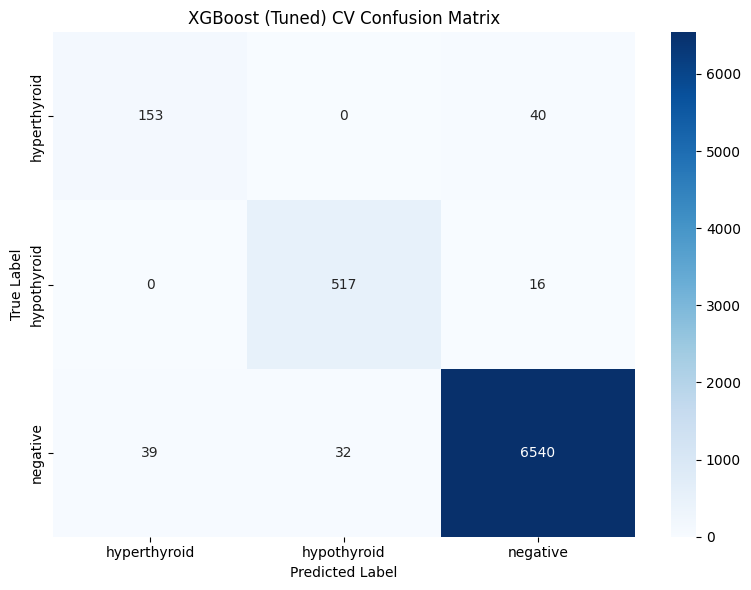

In [ ]:
cm = confusion_matrix(y_train_encoded, y_pred_cv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('XGBoost (Tuned) CV Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Conclusions

**Key Findings:**

- Gradient boosting models (XGBoost/CatBoost) generally outperform our baseline Random Forest
- Hyperparameter tuning provides additional performance gains
- CatBoost's native categorical handling simplifies preprocessing
